In [1]:
from pathlib import Path
from datetime import datetime, date
import xarray as xr

from wekeo_combined_chain import config

def get_combined_ds(date: date) -> xr.Dataset:
    """
    TODO: replace with S3 access instead
    """
    base = config.gridded_combined_downloaded_dir
    file = base / date.strftime("%Y_%m_%d/COMBINED_%Y-%m-%d_v1.0.nc")
    return xr.open_dataset(file)


day = date(2025, 8, 2)              # good date for showcasing plumes
date_str = day.strftime("%Y%m%d")   # used for later plots

ds = get_combined_ds(day)           # query the afformentionned date

print(ds)

<xarray.Dataset> Size: 942MB
Dimensions:                                 (latitude: 1636, longitude: 3272)
Coordinates:
  * latitude                                (latitude) float64 13kB -90.0 ......
  * longitude                               (longitude) float64 26kB -180.0 ....
Data variables: (12/44)
    s5p_pca__cloud_fraction_mean            (latitude, longitude) float32 21MB ...
    s5p_pca__score_CO_1_mean                (latitude, longitude) float32 21MB ...
    s5p_pca__score_CO_2_mean                (latitude, longitude) float32 21MB ...
    s5p_pca__score_CO_3_mean                (latitude, longitude) float32 21MB ...
    s5p_pca__diag_CO_1_mean                 (latitude, longitude) float32 21MB ...
    s5p_pca__diag_CO_2_mean                 (latitude, longitude) float32 21MB ...
    ...                                      ...
    frp_slstr__day_FRP_SWIR_no_SAA_max      (latitude, longitude) float32 21MB ...
    frp_slstr__night_FRP_SWIR_no_SAA_mean   (latitude, longitude

In [ ]:
areas = {
    "Global":          [ 90., -90.,  180., -180.],
    "North_America":   [ 90.,   9.,  -20., -169.],
    "South_America":   [  9., -60.,  -20.,  120.],
    "Europe":          [ 90.,  36.,   31.,  -20.],
    "Africa":          [ 36., -60.,   60.,  -20.],
    "Russia":          [ 90.,  36., -169.,   31.],
    "Asia":            [ 36., -10., -169.,   60.],
    "Australia":       [-10., -60., -120.,   60.],
    # "Central_Pacific": [  9., -10., -120., -169.],
    # "Antarctic":       [-60., -90.,  180., -180.],
}
    
from wekeo_combined_chain.utils import select_area

area_name = "Global"
area = areas[area_name]

## User override example:
# area_name = "User defined: France"
# area = [53., 41., 9., -5.]
    
ds_area = select_area(ds, area)

In [3]:
from wekeo_combined_chain import postprocess

ds_post, df_plumes = postprocess.compute(ds_area)

--> Active FRP cells (filtered): 8
--> 0 plumes
Plumes with FRP: 0


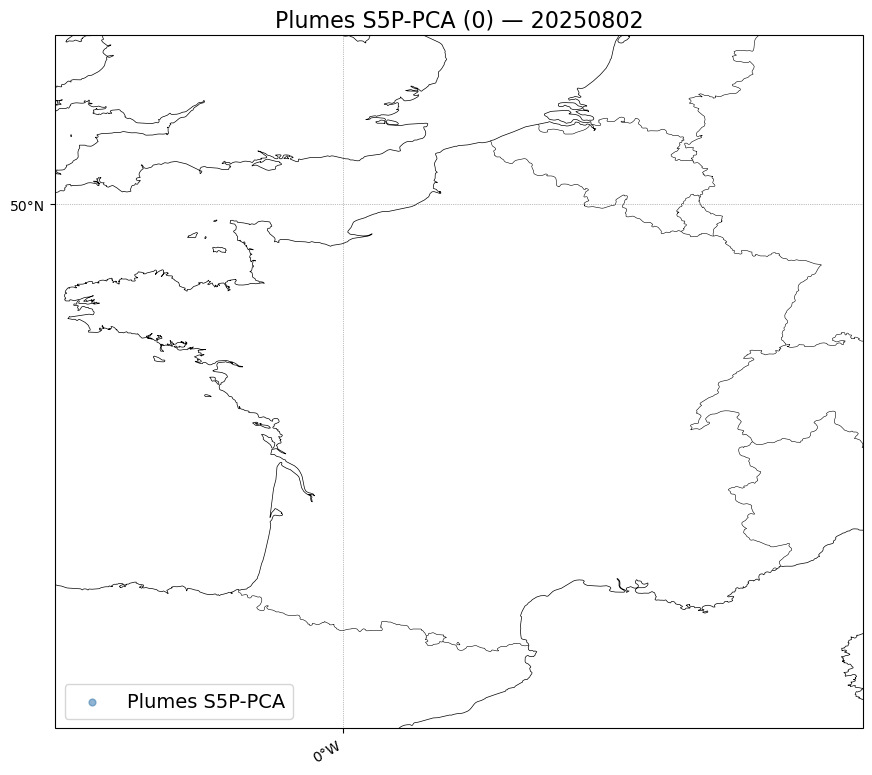

In [4]:
from wekeo_combined_chain.postprocess import plot as P

P.plot_plumes(ds_area, ds_post, date_str)

In [5]:
from wekeo_combined_chain.postprocess import table as T

print("Plumes:")
print("-" * 75)
print(T.plume_table(df_plumes))

print()
print("Tiny plumes:")
print("-" * 75)
print(T.tiny_plume_table(df_plumes))

Plumes:
---------------------------------------------------------------------------
Empty DataFrame
Columns: [Plume label, Number of pixels, Latitude (°), Longitude (°)]
Index: []

Tiny plumes:
---------------------------------------------------------------------------
Empty DataFrame
Columns: [Plume label, Number of pixels, Latitude (°), Longitude (°)]
Index: []


## Map 1 — Plumes × FRP overlay

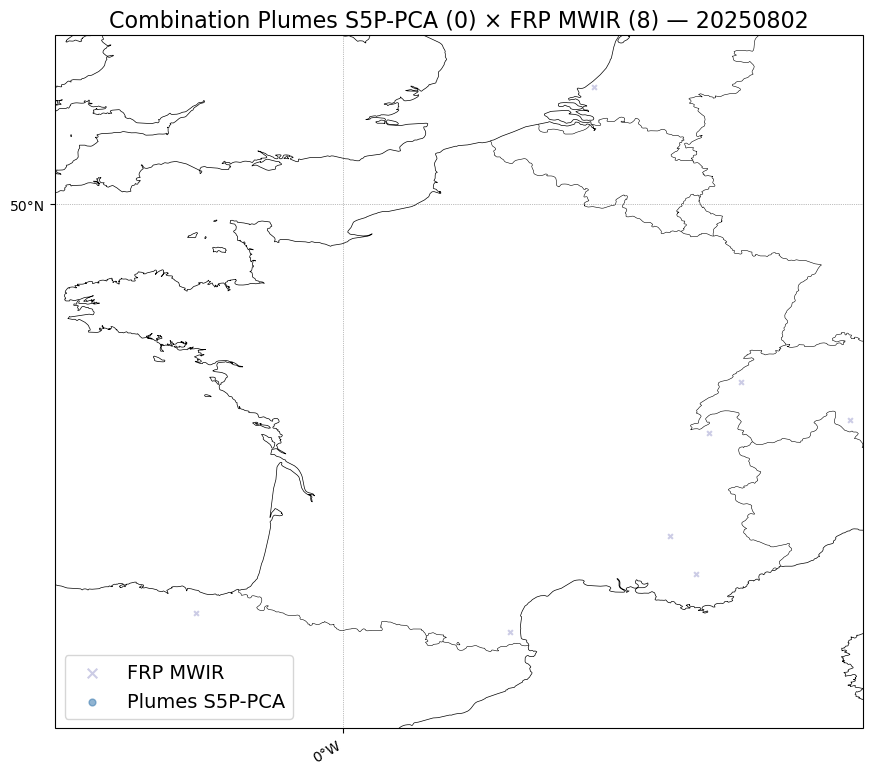

In [6]:
# Toggle save_to to write to disk, or leave None for inline display only
P.plot_plumes_frp(ds_area, ds_post, date_str, frp_channel="MWIR")

## Map 2 — Fire score per plume

In [7]:
P.plot_fire_score_plume(ds_area, ds_post, df_plumes, date_str, band="MWIR")

'No data to plot'

## Map 3 — Fire score per pixel

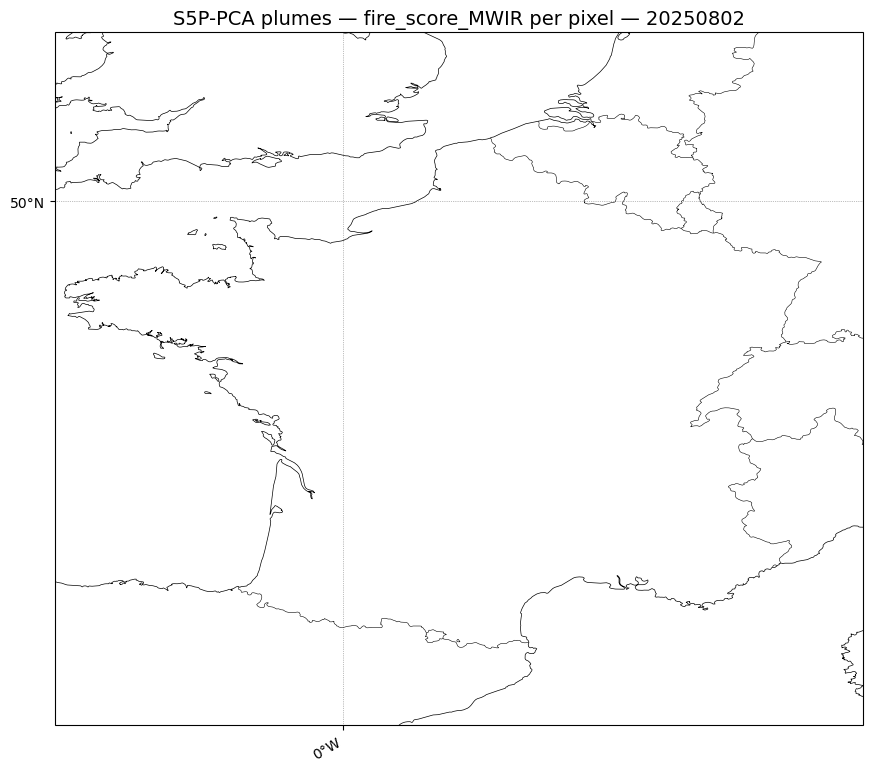

In [8]:
P.plot_fire_score_pixel(ds_area, ds_post, date_str, band="MWIR")
# NOTE: maybe to remove

## Map 4 — Plume envelopes + source confidence

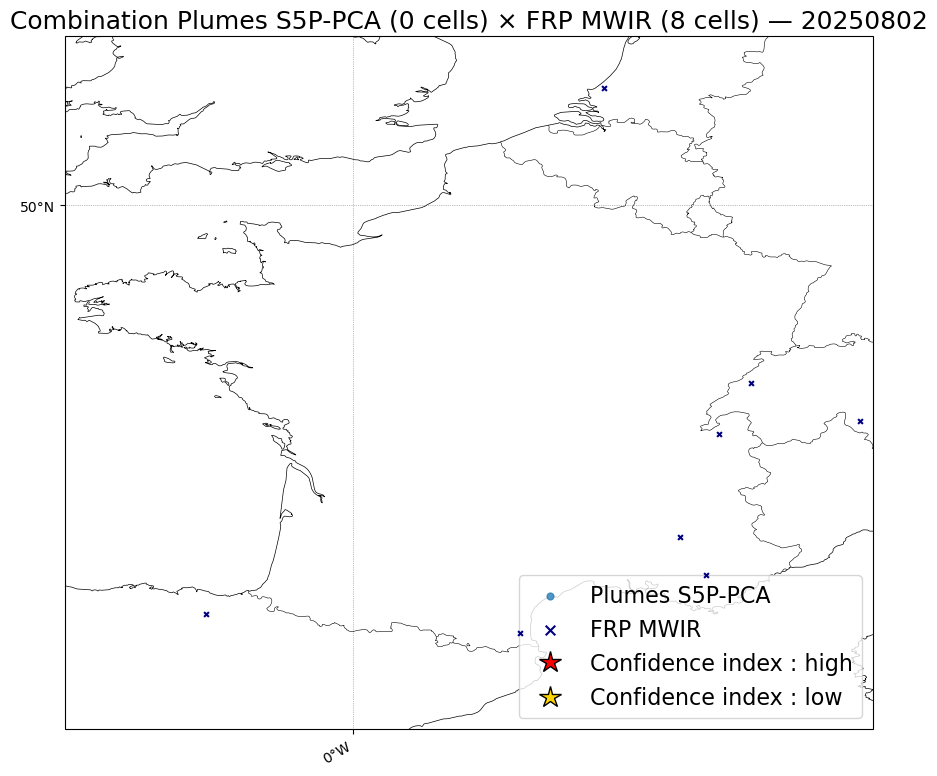

In [9]:
P.plot_plume_envelopes(ds_area, ds_post, df_plumes, date_str, frp_channel="MWIR")

In [ ]:
# end of demo